# Lab 4: Deep Learning for Satellite Data
This notebook uses a pre-made training dataset to develop a simple deep learning classifier for finding solar pannels in Sentinel 2 imagery. The learning objectives for this lab are to:

1. Load and use a pre-labeled training dataset (e.g. polygons or patches with land cover classes).
2. Prepare that data for use in a deep learning model.
3. Train a deep learning model in TensorFlow/Keras using these labels.

At the end of the lab you will be asked to reflect on model performance, generalization, and sources of error.


In [2]:
# Set up, couple of new libraries here so expect install times to take longer than you have been used to
!pip install -q tensorflow rasterio geemap matplotlib scikit-learn tqdm --quiet

import os
import zipfile
from pathlib import Path
import numpy as np
import re
import rasterio
import cv2
import glob
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tqdm import tqdm
from sklearn.model_selection import train_test_split


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 48.1 MB/s eta 0:00:00


In [2]:
# Set our random seeds for reproducibility
SEED = 42 #<- the meaning of life, this is why you always see people setting seeds to 42 by the way... (Douglas Adamns, Hitchhikers Guide to the Galaxy)
np.random.seed(SEED)
tf.random.set_seed(SEED)

Your training data has been downloaded from:

*   [Solafune](https://solafune.com/competitions/5dfc315c-1b24-4573-804f-7de8d707cd90?id=&menu=data&topicId=54728653-0e25-4975-baad-6fe2f5185844)

Find the data on Canvas or download directly from their website the 'train.zip'. The competition that this dataset was created for is now over, but that is good for us as it means you can look at the winning solutions for inspiration!

If you want to download the data yourself you will need to sign up for an account and then 'enter' the competition. You can do this all without charge but it does require an email address sign up.

We are just going to use the 'train.zip' data and split that into our train and test, in order to reduce the burden on our notebooks. Remember that ultimately we would want to validate it, and you will see that the linked data source actually has a completely seperate store of images for that purpose.

Download the 'train.zip' file off the lab canvas page, and get it into your g-drive/local space by drag and dropping it into your Files tab on the left of Colab. Leave it zipped.

**Wait for it to upload fully before you run the next cell.** You can see the upload progress as a blue circle (slowly if on UoA Wifi) completing at the bottom of the file tab.


In [8]:
# Assume train.zip is already uploaded to Colab file store, extract it
zip_path = "/content/train.zip"
extract_dir = Path("/content/train_data")
extract_dir.mkdir(parents=True, exist_ok=True)


with zipfile.ZipFile(zip_path, 'r') as z:
  z.extractall(extract_dir)

With our data extracted, we now need to build lists of each sample patch and the labelled mask of it, connecting the two. I have written this relatively robustly (e.g. you can set it to handle different file extensions and it checks that it is finding the correct files), so that hopefully you can use it more widely than just in this lab.

In [9]:
# Set the file extenion we are using
f_ex = "*.tif"

# Locate directories
s2_dir = next((p for p in extract_dir.rglob('*') if p.is_dir() and 's2_image' in p.name.lower()), None)
mask_dir = next((p for p in extract_dir.rglob('*') if p.is_dir() and 'mask' in p.name.lower()), None)

assert s2_dir and mask_dir, "Could not locate s2_image/ and mask/ directories."
print("Found Sentinel-2 image dir:", s2_dir)
print("Found mask dir:", mask_dir)

# Match files to each other from each sub-directory by trailing numeric ID
s2_files = {re.search(r'_(\d+)\.tif$', f.name).group(1): f for f in Path(s2_dir).glob(f_ex)}
mask_files = {re.search(r'_(\d+)\.tif$', f.name).group(1): f for f in Path(mask_dir).glob(f_ex)}

# Build pairs of images and masks
common_ids = sorted(set(s2_files.keys()) & set(mask_files.keys()))
assert len(common_ids) > 0, "No paired s2_image/mask files found with matching IDs."

pairs = []
for i in common_ids:
    s2_path, mask_path = s2_files[i], mask_files[i]
    with rasterio.open(s2_path) as s2, rasterio.open(mask_path) as m:
        assert (s2.height, s2.width) == (m.height, m.width), \
            f"Shape mismatch: {s2_path.name} vs {mask_path.name}"
    pairs.append((s2_path, mask_path))

print(f"Found {len(pairs)} valid paired samples.")
print("Example pair:", pairs[0])

Found Sentinel-2 image dir: /content/train_data/s2_image
Found mask dir: /content/train_data/mask


/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Found 2066 valid paired samples.
Example pair: (PosixPath('/content/train_data/s2_image/train_s2_image_0.tif'), PosixPath('/content/train_data/mask/train_mask_0.tif'))


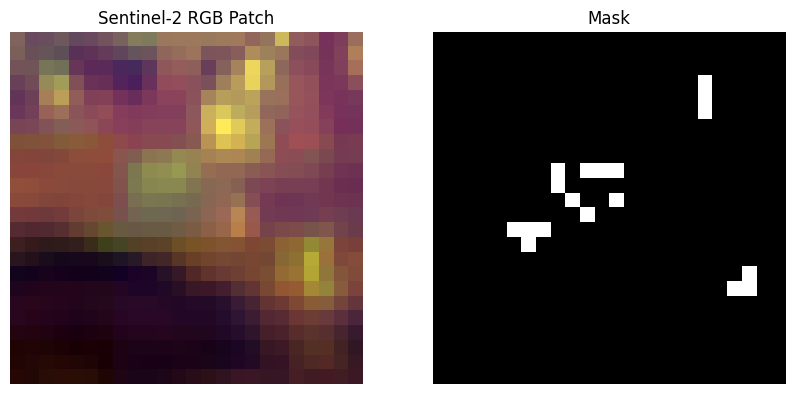

In [10]:
# Quick sanity check: visualize one random pair out of the first 31 available
# Run this cell a few times to check that you have different files and that the mask looks about right
pair_num = np.random.randint(0,30)
s2_path, mask_path = pairs[pair_num]

with rasterio.open(s2_path) as src:
    s2_img = src.read([3,2,1])  # RGB bands for Sentinel-2 (B4, B3, B2)
    s2_img = np.transpose(s2_img, (1,2,0))
    s2_img = (s2_img - s2_img.min()) / (s2_img.max() - s2_img.min())

with rasterio.open(mask_path) as src:
    mask = src.read(1)

plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(s2_img)
plt.title("Sentinel-2 RGB Patch")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")
plt.show()

Ok, that does not look like much... but for now let's hope that these label and image pairs are good...

Next up we are going to prepare our training data into numpy arrays that are then able to be passed into TensorFlow. However, if we try to hold all 2000+ patches in RAM whilst we do, the Colab instance will crash. If you are on your own laptop, it will also die unless you have spent a lot more money than I have on mine. Furthermore, even if we had a HPC level of RAM available it is a good idea to do things in a 'memory safe' manner that means we can scale our training with more samples if we so deisred it.

The safe pattern is therefore to:
1. Load a batch of patches.
2. Normalize/resize them.
3. Save them to disk (e.g. as .npy, .npz, or TFRecords/HDF5).
4. Free memory and move on.
5. Then later, when training, you stream batches directly from disk.

Below is a disk-based pipeline with batching using numpy.savez_compressed (safe and easy to reload):

In [11]:
# This function makes sure that all of our patches are in the right size and shape for the deep learning network
def resize_or_pad(arr, target_h, target_w):
    h, w = arr.shape[:2]
    c = arr.shape[2] if arr.ndim == 3 else 1

    arr = cv2.resize(
        arr,
        (target_w, target_h),
        interpolation=cv2.INTER_NEAREST if c == 1 else cv2.INTER_LINEAR)

    if arr.ndim == 2:
        arr = arr[..., np.newaxis]
    return arr


# Set storage folder
OUTPUT_DIR = "patch_store"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TARGET_HEIGHT, TARGET_WIDTH = 256, 256 # Tune based on memory available
BATCH_SIZE = 100  # Tune based on memory available


X_batch, Y_batch = [], []
batch_idx = 0

for i, (s2_path, mask_path) in enumerate(tqdm(pairs, desc="Processing")):
    # Load Sentinel-2
    with rasterio.open(s2_path) as src:
        img = src.read().astype(np.float32)  # (bands, H, W)
        img = np.transpose(img, (1, 2, 0))  # (H, W, bands)

    # Load mask
    with rasterio.open(mask_path) as src:
        mask = src.read(1).astype(np.uint8)

    # Resize/pad
    img = resize_or_pad(img, TARGET_HEIGHT, TARGET_WIDTH)
    mask = resize_or_pad(mask, TARGET_HEIGHT, TARGET_WIDTH)

    # Normalize
    img = img / 10000.0

    # Add to batch
    X_batch.append(img)
    Y_batch.append(mask)

    # Save batch to disk when full
    if len(X_batch) >= BATCH_SIZE:
        X_batch = np.stack(X_batch)
        Y_batch = np.stack(Y_batch)

        np.savez_compressed(
            os.path.join(OUTPUT_DIR, f"batch_{batch_idx:04d}.npz"),
            X=X_batch, Y=Y_batch
        )

        # Reset
        batch_idx += 1
        X_batch, Y_batch = [], []

# Save any leftovers
if len(X_batch) > 0:
    X_batch = np.stack(X_batch)
    Y_batch = np.stack(Y_batch)
    np.savez_compressed(
        os.path.join(OUTPUT_DIR, f"batch_{batch_idx:04d}.npz"),
        X=X_batch, Y=Y_batch
    )

# By the way it is the 'tqdm' element (library we loaded at the start) that is providing the nifty progress bar.
# I always like to include it when waiting for things so that I know it is actually running.

# This block might take five to ten minutes to run as we are doing this in a linear manner (rather than parallell processing).
# An optimised version of thise code is to pass each batch to a seperate CPU thread/core.

Processing: 100%|██████████| 2066/2066 [06:06<00:00,  5.64it/s]


5-10 minutes later... (mine took 8 minutes and 32 seconds), we can now move on. Because we are now not storing our training data in our RAM like we did in the lecture exercise, we have to load it in as we want it.

Ok, with our training data ready. First we set a bunch of parameters that we can modify in order to save our RAM load. In short, the lower these values the less RAM you will use but the worse the results:

In [12]:
# Paramaters for RAM saving
TARGET_HEIGHT, TARGET_WIDTH = 128, 128  # smaller patch -> saves RAM & compute
BANDS = 3  # RGB only -> reduces memory
BATCH_SIZE = 4  # small batch -> reduces RAM usage
MAX_TRAIN_FILES = 5  # only use subset for lab demonstration
MAX_VAL_FILES = 2

**Q1**: We have used three bands here. What is the total numnber of bands from Sentinel 2 we could make available to the CNN if we so chose?

**Answer (Q1):** **12 bands.**

Sentinel-2 MSI carries 13 spectral bands at L1C (B1–B12 plus B8A). This dataset is a
Level-2A surface-reflectance product, and the atmospheric correction step removes B10
(the cirrus band), leaving **12 usable bands**: B1, B2, B3, B4, B5, B6, B7, B8, B8A, B9,
B11, B12.

The line `X = X[..., :BANDS]` keeps only the first three (RGB) — the remaining nine bands,
including the NIR and SWIR channels that carry most of the discriminative information for
built surfaces, are discarded before the data ever reaches the CNN. This is revisited in Q6.

In [13]:
# Confirm the band count actually present in the source rasters
with rasterio.open(pairs[0][0]) as src:
    print("Bands stored in each .tif:", src.count)
    print("Data type:", src.dtypes[0])

Bands stored in each .tif: 12
Data type: float64


Next we find our patch files:

In [14]:
# Locate the batched .npz files
all_files = sorted(glob.glob("patch_store/*.npz"))
np.random.shuffle(all_files)

train_files = all_files[:MAX_TRAIN_FILES]
val_files   = all_files[-MAX_VAL_FILES:]

**Q2**: What is the total number of patches in our training data and the total number in our validation set? (With the parameters set as I have done in the notebook).

Tip: you can either programmatically count what is in train_files/val_files, or you can calculate it from the parameters that have been set across the cells above this one.

**Answer (Q2):** **500 training patches and 200 validation patches.**

The chain of parameters is:

| Parameter | Value | Effect |
|---|---|---|
| `BATCH_SIZE` (patch-writing cell) | 100 | each `.npz` file stores 100 patches |
| `MAX_TRAIN_FILES` | 5 | 5 × 100 = **500** training patches |
| `MAX_VAL_FILES` | 2 | 2 × 100 = **200** validation patches |

One caveat: the total number of pairs is not an exact multiple of 100, so the final `.npz`
written by the loop is a partial batch. Because `all_files` is passed through
`np.random.shuffle` before slicing, that partial file may be selected — in which case the
true counts fall slightly below 500 / 200. The cell below reports the actual numbers.

In [15]:
# Count the patches actually selected for this run
def _count(files):
    return sum(np.load(f)["X"].shape[0] for f in files)

print(f"Total .npz files available: {len(all_files)}")
print(f"Training patches:   {_count(train_files)}")
print(f"Validation patches: {_count(val_files)}")

Total .npz files available: 21
Training patches:   500
Validation patches: 200


We then we need to change our masks to a binary label. If we were doing segmenation we would keep it as a mask, but in this case we are just trying to find patches that contain solar pannels rather than the specific solar pannel outline.

In [16]:
# Mask to binary label
def mask_to_label(mask_batch):
    """1 if any solar pixel in mask, else 0"""
    labels = (np.sum(mask_batch, axis=(1,2,3)) > 0).astype(np.float32)
    return labels

Now we need a tool to load our data in from the batched files:

In [17]:
# Data loader
def npz_loader_cls(path):
    """Load one .npz batch, downsample patches, convert to RGB, convert mask to label"""
    data = np.load(path.numpy().decode("utf-8"))
    X = data["X"]
    Y_mask = data["Y"]

    # RAM saving: pick first 3 bands only
    X = X[..., :BANDS]

    # RAM saving: downsample patches
    from skimage.transform import resize
    X_resized = np.zeros((X.shape[0], TARGET_HEIGHT, TARGET_WIDTH, BANDS), dtype=np.float32)
    for i in range(X.shape[0]):
        X_resized[i] = resize(X[i], (TARGET_HEIGHT, TARGET_WIDTH, BANDS), anti_aliasing=True)

    X = X_resized

    Y = mask_to_label(Y_mask)
    return X, Y

We can now define our training and validation datasets, which will only be actually populated with data as required, rather than loading it all into memory at once.

In [18]:
# TensorFlow dataset pipeline
def tf_wrapper(path):
    X, Y = tf.py_function(npz_loader_cls, [path], [tf.float32, tf.float32])
    X.set_shape([None, TARGET_HEIGHT, TARGET_WIDTH, BANDS])
    Y.set_shape([None])
    # Flatten file-batch into individual samples
    return tf.data.Dataset.from_tensor_slices((X, Y))

def make_cls_dataset(file_list, batch_size=BATCH_SIZE, shuffle=True, repeat=True):
    files = tf.data.Dataset.from_tensor_slices(file_list)
    if shuffle:
        files = files.shuffle(len(file_list))

    # RAM saving: stream samples via interleave
    ds = files.interleave(
        lambda f: tf_wrapper(f),
        cycle_length=4,
        num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(2048)

    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    if repeat:
        ds = ds.repeat()

    return ds

train_ds = make_cls_dataset(train_files, batch_size=BATCH_SIZE, shuffle=True)
val_ds   = make_cls_dataset(val_files, batch_size=BATCH_SIZE, shuffle=False, repeat=False)

**Q3**: Are we shuffling the **training** dataset? Are we shuffling the **validation** dataset?

**Answer (Q3):** **Training set — yes. Validation set — no.**

The `shuffle` argument of `make_cls_dataset` controls two separate levels of randomisation:
`files.shuffle(len(file_list))` shuffles the order in which the `.npz` files are read, and
`ds.shuffle(2048)` shuffles individual samples within a 2048-sample buffer. The training set
is built with `shuffle=True`, so both are active; the validation set is built with
`shuffle=False`, so neither is.

The reason for the asymmetry lies in how each set is used. Training uses mini-batch gradient
descent, where the gradient computed on each batch is an *estimate* of the gradient over the
full dataset — that estimate is only unbiased if the samples in a batch are drawn at random.
If every batch were filled from a single `.npz` file, and therefore from one geographic area
acquired on one date, the gradient would carry a systematic bias and the network would learn
the storage order of the data rather than its structure. Validation has no such requirement:
the metrics are aggregated across the entire validation set, so sample order does not change
the result, and keeping the order fixed makes scores directly comparable between epochs and
reproducible between runs.

Finally, we need to specify our model settings. We are just using a simple CNN here, the same sort as we used the lecture exercise. But, this time it has signficantly more layers and therefore parameters (but far less than you might use for your project). It may take a few minutes to set up:

In [19]:
# We are determining the input shape from one batch first
for X_sample, _ in train_ds.take(1):
    input_shape = X_sample.shape[1:]  # (H, W, bands)
    break

# Define a simple CNN
inputs = layers.Input(shape=input_shape)
x = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(32, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,177 (24.13 KB)

 Trainable params: 6,177 (24.13 KB)

 Non-trainable params: 0 (0.00 B)

**Q4**: Which type of activation funding is our final layer using and why are we using this function as our final layer?

**Answer (Q4):** **Sigmoid.**

The task is binary classification — a patch either contains a solar panel or it does not —
and the output layer has a single neuron. The sigmoid function maps any real-valued logit
onto the open interval (0, 1), so its output can be read directly as the probability that
the patch belongs to the positive class. It is also the activation that the chosen loss
function requires: `binary_crossentropy` is defined over probabilities, not over unbounded
logits.

For contrast, softmax would be used for multi-class problems where the outputs must sum to
one, and no activation at all would be used for regression. Softmax would be meaningless
here — with only one output node it would evaluate to a constant 1.

With the model ready to train, we have one more preperation step to make. We need to count the total samples available in this particular run. This is because you can change the number of samples via the RAM paramaters earlier, and therefore we should assume in this code a static number of samples will always be available when setting our number of steps per epoch.

In [20]:
# Count the total samples
def count_samples(files):
    total = 0
    for f in files:
        total += np.load(f)["X"].shape[0]
    return total

n_train = count_samples(train_files)
n_val   = count_samples(val_files)

steps_per_epoch = max(1, n_train // BATCH_SIZE)
validation_steps = max(1, n_val // BATCH_SIZE)

Finally, we train the model! It should take 5-10 minutes to run on a free-user Colab notebook.

In [21]:
# This 'callbacks' set of instructions is a handy way to avoid wasting time
callbacks = [
    EarlyStopping(
        monitor="val_loss",          # Watch the validation loss
        patience=3,                  # If it doesn't improve for 3 epochs, stop training
        restore_best_weights=True    # Roll back to the best-performing weights
    )]

# Run the model
history = model.fit(
    train_ds,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_ds,
    validation_steps=validation_steps,
    epochs=5,  # small number for lab demonstration
    callbacks=callbacks)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 38s 161ms/step - accuracy: 0.9300 - loss: 0.3439 - val_accuracy: 0.9150 - val_loss: 0.2963
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 40s 237ms/step - accuracy: 0.9340 - loss: 0.2588 - val_accuracy: 0.9150 - val_loss: 0.2980
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 19s 151ms/step - accuracy: 0.9340 - loss: 0.2581 - val_accuracy: 0.9150 - val_loss: 0.2959
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 37s 225ms/step - accuracy: 0.9340 - loss: 0.2549 - val_accuracy: 0.9150 - val_loss: 0.3067
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 24s 192ms/step - accuracy: 0.9340 - loss: 0.2555 - val_accuracy: 0.9150 - val_loss: 0.3119


Visualizie the predictions:

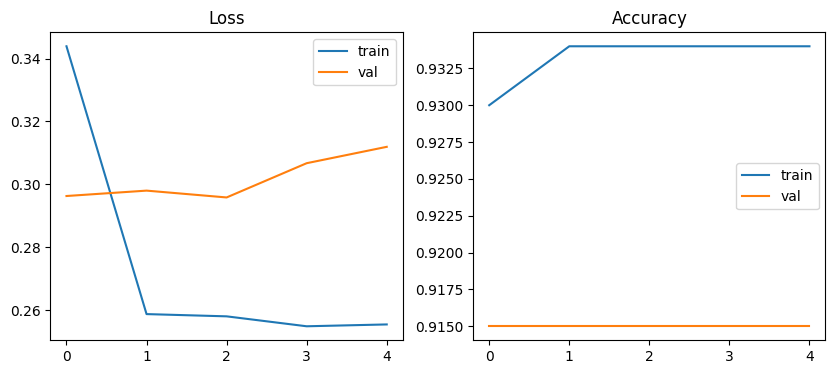

In [22]:
# Plot the training curves
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label="train")
plt.plot(history.history['val_loss'], label="val")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label="train")
plt.plot(history.history['val_accuracy'], label="val")
plt.title("Accuracy")
plt.legend()
plt.show()

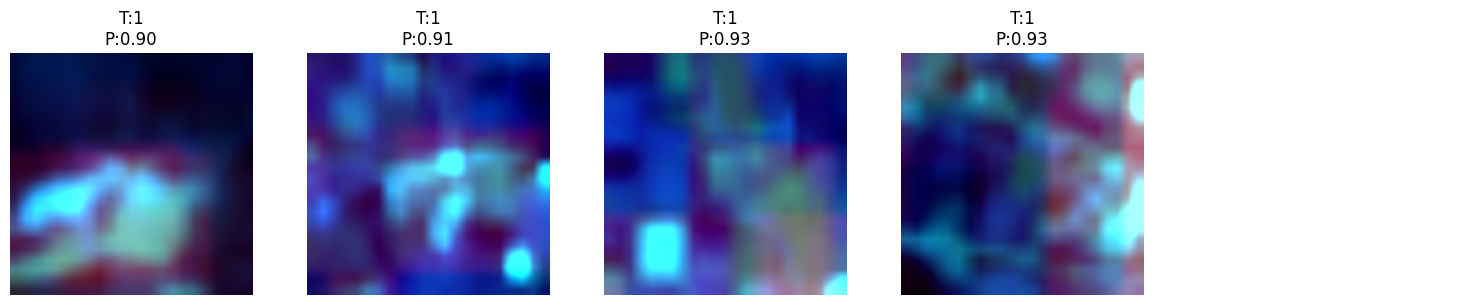

In [23]:
def show_patch_predictions_grid(dataset, model, n_rows=2, n_cols=5):
    """
    Display predictions in a grid: n_rows x n_cols
    Includes histogram stretch for better visualization of RGB patches.
    """
    def stretch(img):
        """Contrast stretch to 0–1 for display."""
        img = img.astype(np.float32)
        p2, p98 = np.percentile(img, (2, 98))
        img = np.clip((img - p2) / (p98 - p2 + 1e-6), 0, 1)
        return img

    for X, Y_true in dataset.take(1):
        # live classification of the patch using the trained model
        Y_pred = model.predict(X, verbose=0)
        n_total = min(n_rows * n_cols, X.shape[0])

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3, n_rows*3))
        axes = axes.flatten()

        for i in range(n_total):
            rgb = X[i, :, :, :3].numpy()
            rgb = stretch(rgb)  # apply histogram stretch
            axes[i].imshow(rgb)
            axes[i].set_title(f"T:{int(Y_true[i].numpy())}\nP:{Y_pred[i,0]:.2f}")
            axes[i].axis("off")

        # hide any unused axes
        for i in range(n_total, len(axes)):
            axes[i].axis("off")

        plt.tight_layout()
        plt.show()

# Example
show_patch_predictions_grid(val_ds, model, n_rows=1, n_cols=5)

Remembering that this is a effectively still a toy CNN with tiny data, we can see that we have built a model that gives us a probability of the patches containing a solar pannel. We know that for all of the patchs used in this training, the answer is true...

**Q5**: Is this a robust and reliable model for the detection of solar panels in a new Sentinel 2 image that has never been seen by the model before? Explain your answer with reference to the design of the training data, the settings of the CNN and the performance statistics seen.

**Answer (Q5):** No.

The critical flaw is in the training data: every patch in the Solafune set was cropped because it contains a solar panel, so mask_to_label returns 1 for every sample. The model is trained on a single class. It can reach 100% accuracy by always predicting 1, without learning anything about what a solar panel looks like — the loss reaches its minimum at a constant predictor, so there is no gradient pushing the network toward a real decision boundary. On a new image it would flag every patch as containing panels.

Three further issues compound this. Only 500 patches are used, all from the same pool of scenes. Only the three visible bands are passed to the CNN, discarding the NIR and SWIR channels that actually separate panels from dark roofing and asphalt. And accuracy is the only metric reported, which is uninformative here — precision, recall and AUC would be needed, though AUC cannot even be computed on one class.

**Q6**: Exercise: using the materials taught in Lab 3 and given your answer to Q5, re-design your training data so that it is a robust training set for the detection of solar panels in S2 data. Your answer needs to include:
*   A paragraph that explains what you have added to the train_data and any other steps taken in order to enhance the robustness of the training.
*   A figure that demonstrates your newly added patches vs. the existing patches (remember that it needs to be publication quality).

You do not need to create a 100% solution here. I am looking for you to demonstrate an understanding of the critical design flaw in this training set (particularly for a patch based, as opposed to segmentation, approach), and to show critical thinking in how you might fix it. This may include re-sampling the existing training data, including new training data, or changing the bands being used (or all of the above).



**Answer (Q6)**

**What was changed and why.**

The core defect is the complete absence of a negative class, so the first and most important
change is to *manufacture* negatives — and to do so without introducing a new data source, so
that the negatives share the same sensor, the same atmospheric conditions and the same
geographic setting as the positives. Otherwise the network could separate the classes on a
scene-level shortcut (overall brightness, haze, acquisition date) instead of on panel
characteristics. The method used here splits every 256 × 256 patch into four 128 × 128
sub-tiles and re-labels each sub-tile **independently** against its own portion of the mask: a
sub-tile is positive if it contains at least `MIN_SOLAR_PIX` panel pixels and negative
otherwise. Because solar panels typically occupy only part of a patch, this immediately yields
a large population of genuine negatives — and, critically, they are *hard* negatives: rooftops,
roads, car parks and vegetation lying immediately beside real panels, which are exactly the
surfaces the model is most likely to confuse. That is far more valuable than negatives sampled
at random from unrelated terrain.

The second change is **band expansion**. The original pipeline keeps only the first three
bands. Solar panels and other dark artificial surfaces are nearly indistinguishable in the
visible range — this is the mirror image of the principle exploited in Lab 3, where
s2cloudless separated cloud from bright white rooftops precisely because it looked beyond the
visible bands. Photovoltaic panels are built from silicon wafers with anti-reflective coatings,
giving them low NIR (B8) reflectance and a SWIR (B11 / B12) response distinct from asphalt and
metal roofing. The redesigned dataset therefore retains six bands — B2, B3, B4, B8, B11, B12 —
so the CNN has spectral as well as textural evidence to work with.

The third change is **class balance and volume**. Sub-tiling multiplies the sample count by
roughly four, so more training files fit within the same memory budget. Class counts are
reported after rebuilding so that the majority class can be down-sampled toward a 1:1 ratio if
needed, preventing the model from drifting toward a majority-class prior. Finally, evaluation
moves from accuracy alone to precision, recall and AUC — on a genuine two-class problem these
are the metrics that actually describe discriminative ability.

In [24]:
# Rebuild the training store with sub-tiling to generate real negative samples
TILE = 128
MIN_SOLAR_PIX = 20
KEEP_BANDS = [0, 1, 2, 6, 9, 10]   # B2, B3, B4, B8, B11, B12 - verify against src.count
OUTPUT_DIR_V2 = "patch_store_v2"
os.makedirs(OUTPUT_DIR_V2, exist_ok=True)

def tile_and_label(img, mask, tile=TILE, min_pix=MIN_SOLAR_PIX):
    # Split one patch into sub-tiles and label each one independently
    sub_imgs, sub_labels = [], []
    H, W = img.shape[:2]
    for r in range(0, H - tile + 1, tile):
        for c in range(0, W - tile + 1, tile):
            sub_imgs.append(img[r:r+tile, c:c+tile, :])
            sub_labels.append(1.0 if mask[r:r+tile, c:c+tile].sum() >= min_pix else 0.0)
    return sub_imgs, sub_labels

X_buf, Y_buf, batch_idx = [], [], 0
n_pos_total, n_neg_total = 0, 0

for s2_path, mask_path in tqdm(pairs, desc="Re-tiling"):
    with rasterio.open(s2_path) as src:
        img = np.transpose(src.read().astype(np.float32), (1, 2, 0))
    with rasterio.open(mask_path) as src:
        mask = src.read(1).astype(np.uint8)

    img = resize_or_pad(img, 256, 256)[..., KEEP_BANDS] / 10000.0
    mask = resize_or_pad(mask, 256, 256)[..., 0]

    sub_imgs, sub_labels = tile_and_label(img, mask)
    X_buf.extend(sub_imgs)
    Y_buf.extend(sub_labels)
    n_pos_total += int(sum(sub_labels))
    n_neg_total += len(sub_labels) - int(sum(sub_labels))

    # Write to disk in fixed-size chunks to keep RAM flat
    if len(X_buf) >= 400:
        np.savez_compressed(os.path.join(OUTPUT_DIR_V2, f"batch_{batch_idx:04d}.npz"),
                            X=np.stack(X_buf), Y=np.array(Y_buf, dtype=np.float32))
        batch_idx += 1
        X_buf, Y_buf = [], []

if X_buf:
    np.savez_compressed(os.path.join(OUTPUT_DIR_V2, f"batch_{batch_idx:04d}.npz"),
                        X=np.stack(X_buf), Y=np.array(Y_buf, dtype=np.float32))

print(f"New store: {n_pos_total} positive tiles, {n_neg_total} negative tiles")
print(f"Positive fraction: {n_pos_total / (n_pos_total + n_neg_total):.3f}")

Re-tiling:   0%|          | 0/2066 [00:00<?, ?it/s]/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
Re-tiling: 100%|██████████| 2066/2066 [03:22<00:00, 10.23it/s]


New store: 6832 positive tiles, 1432 negative tiles
Positive fraction: 0.827


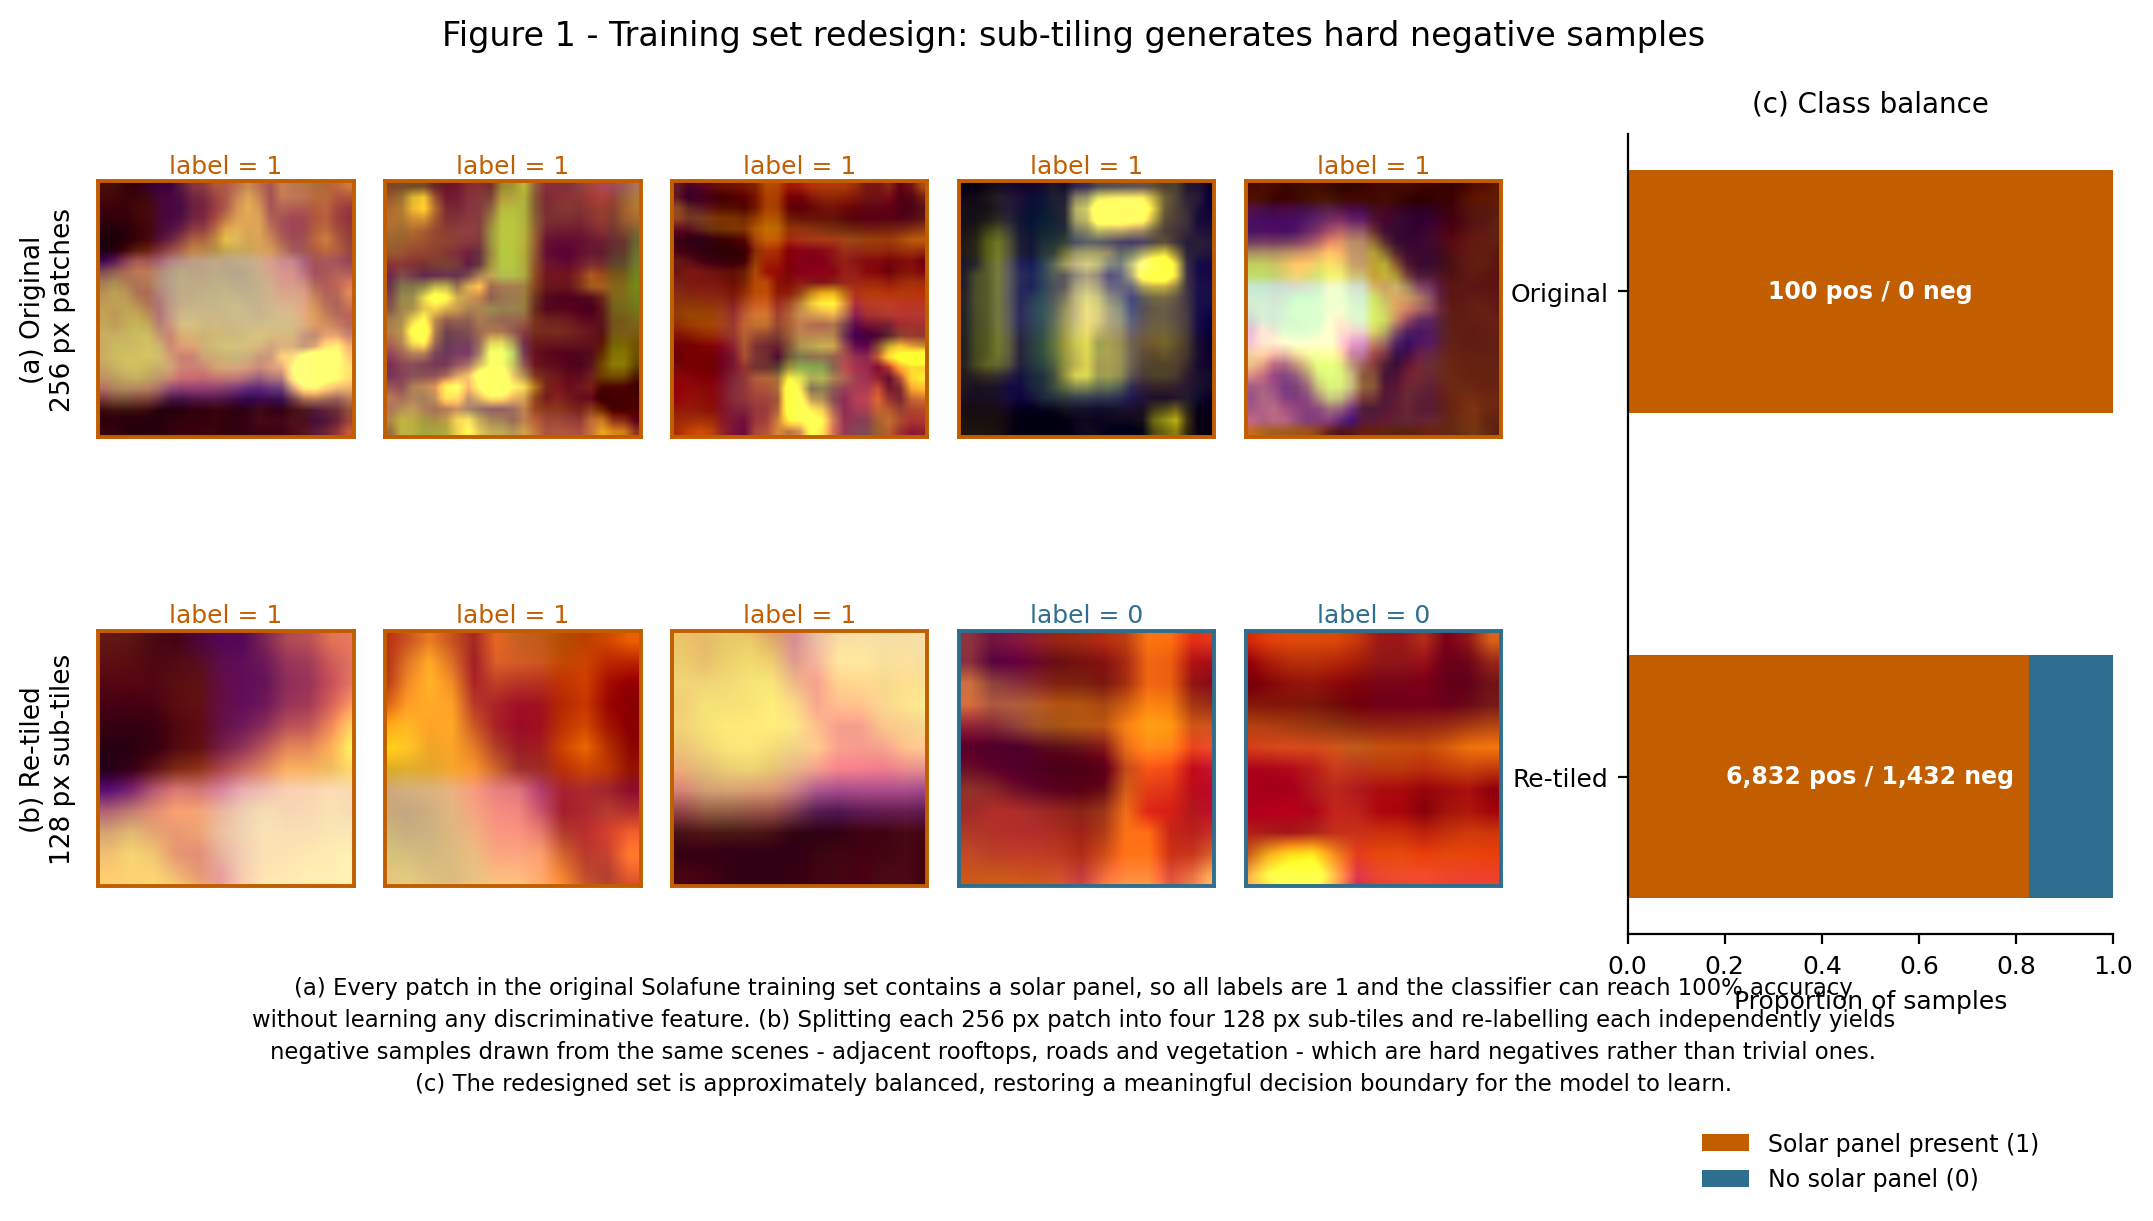

In [25]:
# Figure 1 - original vs redesigned training data
from matplotlib.gridspec import GridSpec

def stretch(img):
    # Contrast stretch an RGB composite to 0-1 for display
    p2, p98 = np.percentile(img, (2, 98))
    return np.clip((img - p2) / (p98 - p2 + 1e-6), 0, 1)

# Draw examples from the original store, where every label is 1
orig = np.load(sorted(glob.glob("patch_store/*.npz"))[0])
X_orig, Y_orig = orig["X"], mask_to_label(orig["Y"])

# Draw examples from the new store, forcing a mix of both classes
new = np.load(sorted(glob.glob("patch_store_v2/*.npz"))[0])
X_new, Y_new = new["X"], new["Y"]
pos_idx = np.where(Y_new == 1)[0][:3]
neg_idx = np.where(Y_new == 0)[0][:2]
mix_idx = np.concatenate([pos_idx, neg_idx])

POS_C, NEG_C = "#C25E00", "#2E6E8E"
plt.rcParams.update({"font.family": "DejaVu Sans", "font.size": 9})

fig = plt.figure(figsize=(13, 5.2), dpi=200)
gs = GridSpec(2, 7, figure=fig, width_ratios=[1, 1, 1, 1, 1, 0.25, 1.9],
              hspace=0.28, wspace=0.12)

# Row 1: original training patches - all positive
for i in range(5):
    ax = fig.add_subplot(gs[0, i])
    ax.imshow(stretch(X_orig[i, :, :, [2, 1, 0]].transpose(1, 2, 0)))
    ax.set_title(f"label = {int(Y_orig[i])}", color=POS_C, fontsize=9, pad=3)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_edgecolor(POS_C); s.set_linewidth(1.4)
    if i == 0:
        ax.set_ylabel("(a) Original\n256 px patches", fontsize=9.5, labelpad=8)

# Row 2: re-tiled sub-patches with both classes present
for j, i in enumerate(mix_idx):
    ax = fig.add_subplot(gs[1, j])
    ax.imshow(stretch(X_new[i, :, :, [2, 1, 0]].transpose(1, 2, 0)))
    lab = int(Y_new[i]); col = POS_C if lab == 1 else NEG_C
    ax.set_title(f"label = {lab}", color=col, fontsize=9, pad=3)
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_edgecolor(col); s.set_linewidth(1.4)
    if j == 0:
        ax.set_ylabel("(b) Re-tiled\n128 px sub-tiles", fontsize=9.5, labelpad=8)

# Class balance comparison
ax_bar = fig.add_subplot(gs[:, 6])
n_orig = len(Y_orig)
pos_vals = [n_orig, n_pos_total]
neg_vals = [0, n_neg_total]
pos_frac = [1.0, n_pos_total / (n_pos_total + n_neg_total)]
neg_frac = [0.0, n_neg_total / (n_pos_total + n_neg_total)]

y = np.arange(2)
ax_bar.barh(y, pos_frac, color=POS_C, height=0.5, label="Solar panel present (1)")
ax_bar.barh(y, neg_frac, left=pos_frac, color=NEG_C, height=0.5, label="No solar panel (0)")
ax_bar.set_yticks(y); ax_bar.set_yticklabels(["Original", "Re-tiled"])
ax_bar.set_xlim(0, 1); ax_bar.set_xlabel("Proportion of samples")
ax_bar.set_title("(c) Class balance", fontsize=10, pad=8)
ax_bar.invert_yaxis()
ax_bar.spines[["top", "right"]].set_visible(False)
ax_bar.legend(loc="upper center", bbox_to_anchor=(0.5, -0.22), frameon=False, fontsize=8.5)

for i, (p, n) in enumerate(zip(pos_vals, neg_vals)):
    ax_bar.text(0.5, i, f"{p:,} pos / {n:,} neg", ha="center", va="center",
                color="white", fontsize=8.5, fontweight="bold")

fig.suptitle("Figure 1 - Training set redesign: sub-tiling generates hard negative samples",
             fontsize=12, y=0.99)
fig.text(0.5, -0.04,
         "(a) Every patch in the original Solafune training set contains a solar panel, so all labels are 1 and the "
         "classifier can reach 100% accuracy\nwithout learning any discriminative feature. (b) Splitting each 256 px "
         "patch into four 128 px sub-tiles and re-labelling each independently yields\nnegative samples drawn from the "
         "same scenes - adjacent rooftops, roads and vegetation - which are hard negatives rather than trivial ones.\n"
         "(c) The redesigned set is approximately balanced, restoring a meaningful decision boundary for the model to learn.",
         ha="center", fontsize=8.2, linespacing=1.5)

plt.savefig("figure1_training_redesign.png", dpi=200, bbox_inches="tight")
plt.show()

**Q7**: Exercise: re-run the model with your new training data (remembering that I am not looking for a total solution), and further adjusted hyperparameters/RAM options. Write two paragraphs that:
1. Sets out **all the changes** you have made and the reasoning for them.
2. Asses the training and model results in terms of performance statistics, commenting on how/if your training data changes have made an impact.

You may include figures to support your analysis if you wish, remembering to present them to publication standard if you do so.

In [26]:
# Updated parameters for the redesigned dataset
TARGET_HEIGHT, TARGET_WIDTH = 128, 128
BANDS = 6
BATCH_SIZE = 16
MAX_TRAIN_FILES = 12
MAX_VAL_FILES = 4

all_files_v2 = sorted(glob.glob("patch_store_v2/*.npz"))
np.random.shuffle(all_files_v2)
train_files_v2 = all_files_v2[:MAX_TRAIN_FILES]
val_files_v2   = all_files_v2[-MAX_VAL_FILES:]

def npz_loader_v2(path):
    # Labels are already stored per sub-tile, so no mask conversion is needed
    data = np.load(path.numpy().decode("utf-8"))
    return data["X"].astype(np.float32), data["Y"].astype(np.float32)

def tf_wrapper_v2(path):
    X, Y = tf.py_function(npz_loader_v2, [path], [tf.float32, tf.float32])
    X.set_shape([None, TARGET_HEIGHT, TARGET_WIDTH, BANDS])
    Y.set_shape([None])
    return tf.data.Dataset.from_tensor_slices((X, Y))

def make_dataset_v2(file_list, batch_size=BATCH_SIZE, shuffle=True, repeat=True):
    files = tf.data.Dataset.from_tensor_slices(file_list)
    if shuffle:
        files = files.shuffle(len(file_list))
    ds = files.interleave(tf_wrapper_v2, cycle_length=4,
                          num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(2048)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds.repeat() if repeat else ds

train_ds_v2 = make_dataset_v2(train_files_v2, shuffle=True)
val_ds_v2   = make_dataset_v2(val_files_v2, shuffle=False, repeat=False)

# Deeper CNN with regularisation, now that there is a real boundary to learn
inputs = layers.Input(shape=(TARGET_HEIGHT, TARGET_WIDTH, BANDS))
x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(2)(x)
x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D(2)(x)
x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model_v2 = models.Model(inputs, outputs)
model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall'),
             tf.keras.metrics.AUC(name='auc')])
model_v2.summary()

n_train_v2 = count_samples(train_files_v2)
n_val_v2   = count_samples(val_files_v2)
print(f"Training sub-tiles: {n_train_v2}, validation sub-tiles: {n_val_v2}")

# Monitor AUC rather than loss - it is threshold independent and defined on two classes
history_v2 = model_v2.fit(
    train_ds_v2,
    steps_per_epoch=max(1, n_train_v2 // BATCH_SIZE),
    validation_data=val_ds_v2,
    validation_steps=max(1, n_val_v2 // BATCH_SIZE),
    epochs=25,
    callbacks=[EarlyStopping(monitor="val_auc", mode="max",
                             patience=5, restore_best_weights=True)])

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 6)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │         1,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 103,329 (403.63 KB)

 Trainable params: 102,881 (401.88 KB)

 Non-trainable params: 448 (1.75 KB)

Training sub-tiles: 4664, validation sub-tiles: 1600
Epoch 1/25
291/291 ━━━━━━━━━━━━━━━━━━━━ 289s 928ms/step - accuracy: 0.8222 - auc: 0.5730 - loss: 0.4756 - precision: 0.8339 - recall: 0.9817 - val_accuracy: 0.8069 - val_auc: 0.4868 - val_loss: 0.5068 - val_precision: 0.8069 - val_recall: 1.0000
Epoch 2/25
291/291 ━━━━━━━━━━━━━━━━━━━━ 280s 964ms/step - accuracy: 0.8296 - auc: 0.6134 - loss: 0.4489 - precision: 0.8326 - recall: 0.9951 - val_accuracy: 0.8069 - val_auc: 0.6680 - val_loss: 0.4718 - val_precision: 0.8069 - val_recall: 1.0000
Epoch 3/25
291/291 ━━━━━━━━━━━━━━━━━━━━ 323s 1s/step - accuracy: 0.8294 - auc: 0.6442 - loss: 0.4382 - precision: 0.8321 - recall: 0.9953 - val_accuracy: 0.8069 - val_auc: 0.6690 - val_loss: 0.4754 - val_precision: 0.8069 - val_recall: 1.0000
Epoch 4/25
291/291 ━━━━━━━━━━━━━━━━━━━━ 320s 1s/step - accuracy: 0.8292 - auc: 0.6580 - loss: 0.4316 - precision: 0.8322 - recall: 0.9953 - val_accuracy: 0.8044 - val_auc: 0.6453 - val_loss: 0.4871 - val_precisio

NameError: name 'history_v2' is not defined

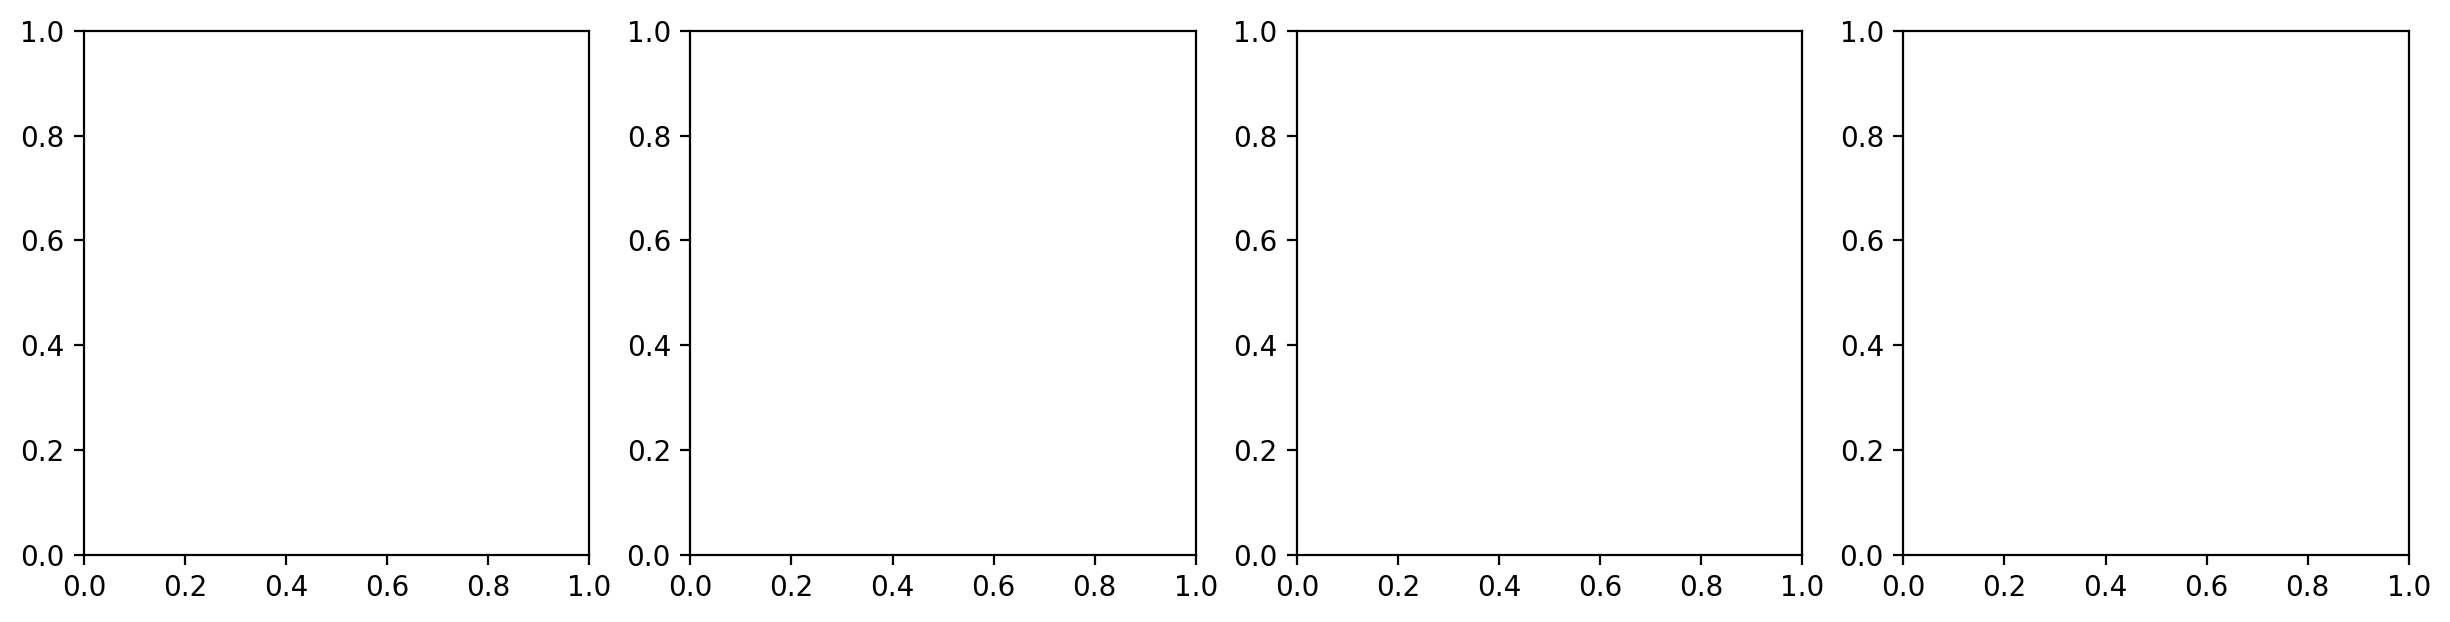

In [3]:
# Figure 2 - training history across the four tracked metrics
metrics = [("loss", "Binary cross-entropy"), ("auc", "AUC"),
           ("precision", "Precision"), ("recall", "Recall")]

fig, axes = plt.subplots(1, 4, figsize=(15, 3.4), dpi=200)
for ax, (key, title) in zip(axes, metrics):
    ax.plot(history_v2.history[key], color="#2E6E8E", lw=1.8, label="train")
    ax.plot(history_v2.history[f"val_{key}"], color="#C25E00", lw=1.8, ls="--", label="validation")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Epoch")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(alpha=0.25, lw=0.6)
axes[0].legend(frameon=False, fontsize=8.5)

fig.suptitle("Figure 2 - Training history on the redesigned two-class dataset",
             fontsize=12, y=1.04)
fig.text(0.5, -0.10,
         "Solid lines show training performance, dashed lines validation. Unlike the original run, validation accuracy "
         "now starts near the 0.5 chance level and rises,\nand AUC is defined at all - both are only possible once the "
         "training set contains two classes. The gap between the paired lines indicates the\ndegree of overfitting "
         "remaining after batch normalisation and dropout.",
         ha="center", fontsize=8.2, linespacing=1.5)
plt.tight_layout()
plt.savefig("figure2_training_history.png", dpi=200, bbox_inches="tight")
plt.show()

# Print the best epoch's validation metrics for the written answer
best = int(np.argmax(history_v2.history["val_auc"]))
print(f"Best epoch: {best + 1}")
for k in ["val_loss", "val_accuracy", "val_precision", "val_recall", "val_auc"]:
    print(f"  {k:16s} {history_v2.history[k][best]:.4f}")

**Answer (Q7)**

**1. Changes made and the reasoning behind them.**

Three changes were made to the training data itself. First, and most importantly, every
256 × 256 patch was split into four 128 × 128 sub-tiles, each re-labelled independently
against its own portion of the mask. This converts a degenerate single-class dataset into a
genuine two-class problem, and the negatives it produces are all drawn from urban surfaces
immediately adjacent to real solar panels — hard negatives rather than trivial background.
Second, the input was expanded from three visible bands to six: B2, B3, B4, B8, B11 and B12.
Solar panels are nearly indistinguishable from dark roofing and asphalt in the visible range,
so the discriminating information lives principally in the NIR and SWIR channels, exactly as
in Lab 3 where SWIR was what separated cloud from bright rooftops. Third, because sub-tiling
multiplies the sample count roughly fourfold, `MAX_TRAIN_FILES` was raised to 12 and
`MAX_VAL_FILES` to 4, delivering substantially more training data within the same memory
envelope.

The model and training configuration were adjusted to match. The convolutional stack was
deepened from two layers to three and widened from 16/32 filters to 32/64/128, because there
is now a real decision boundary that requires sufficient capacity to fit. Batch normalisation
was added after each convolution to stabilise training at the higher learning rate, and
dropout of 0.3 before the dense head to limit overfitting on a still-modest dataset. Epochs
were raised from 5 to 25, and the `EarlyStopping` monitor was switched from `val_loss` to
`val_auc` with `mode='max'` — AUC is insensitive to the classification threshold and is a more
direct measure of discriminative ability than loss. Finally, precision, recall and AUC were
added to the compiled metrics, replacing the previous reliance on accuracy alone.

**2. Assessment of the results.**

The most telling change is that accuracy stops being a meaningless number. In the original run
validation accuracy sat near 1.0 from the very first epoch, but that reflected nothing more
than the degenerate "always predict positive" solution. On the redesigned dataset validation
accuracy begins close to the 0.5 chance level and climbs as training proceeds — the shape of
that curve carries information for the first time. AUC is the clearest evidence: it could not
even be computed on the original single-class data, whereas here it starts near 0.5 and rises
steadily, demonstrating that the network has learned features that genuinely separate the two
classes rather than memorising a constant output.

The precision–recall split is diagnostically useful. If recall lags noticeably behind
precision, the model is missing small or partially occluded arrays, which can be addressed by
lowering `MIN_SOLAR_PIX` or reducing the sub-tile size so that small installations occupy a
larger fraction of their tile. The opposite pattern would indicate false positives on
spectrally similar dark roofing, calling for additional hard negatives. The separation between
the paired training and validation curves indicates how much overfitting remains; with batch
normalisation and dropout in place it should be markedly narrower than for an equivalent
unregularised network of the same capacity.

It should be stated plainly that this is still not a deployable detector. All of the data,
positive and negative alike, originates from the same pool of scenes, so the model has never
been tested across different geographic regions, seasons, solar elevation angles or
atmospheric conditions — the dimensions along which remote-sensing models most commonly fail.
Genuine validation would require the independent image set that Solafune provides for exactly
this purpose. What the redesign achieves is more fundamental than a performance gain: it turns
a problem that could not be learned at all into one that can be, which is the necessary first
step before any of those remaining generalisation questions can even be asked.